In [7]:
print("""Goal of this project - 
      
      Perform sentiment analysis on a dataset of Twitter posts using Recurrent Neural Networks (RNN). 
      The goal is to classify the sentiment of tweets as positive, negative, or neutral based on the text data.
      
      High Level Steps - 
      1. Preprocess the data
      2. Conduct exploratory data analysis (EDA)
      3. Build an RNN model for sentiment classification
      4. Evaluate the performance of your model. 
""")

Goal of this project - 
      
      Perform sentiment analysis on a dataset of Twitter posts using Recurrent Neural Networks (RNN). 
      The goal is to classify the sentiment of tweets as positive, negative, or neutral based on the text data.
      
      High Level Steps - 
      1. Preprocess the data
      2. Conduct exploratory data analysis (EDA)
      3. Build an RNN model for sentiment classification
      4. Evaluate the performance of your model. 



In [8]:
#conda install tensorflow
#nltk.download('wordnet')
#pip install joblib
#pip install wordcloud

In [9]:
import os
import pandas as pd
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from collections import Counter
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from joblib import Parallel, delayed

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, f1_score, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

In [10]:
# Import the dataset from csv file into data frames 
twitter_posts_df = pd.read_csv('/Users/ravvarma/Documents/Personal/AI & ML IITM /Week_31/Graded_Project/twitter_training.csv')
twitter_posts_df.head(10)

# Summary of Data set before cleaning 
print(twitter_posts_df.describe())
print(twitter_posts_df.shape)

# Keep only the necessary columns - TweetedText and Sentiment 
df = twitter_posts_df[['TweetedText', 'Sentiment']].copy()

                 Id
count  74682.000000
mean    6432.586165
std     3740.427870
min        1.000000
25%     3195.000000
50%     6422.000000
75%     9601.000000
max    13200.000000
(74682, 4)


In [11]:
print(""" 
Data Cleaning and Preparation:

Step-1 : Cleaning the data set 
1. Check for and handle missing values in the dataset.
      - Taken an approach to drop the rows with missing tweet text. 
      - Since the number of rows with missing tweet text is very small (858) compared to overall tweet text rows (74681)
      - Further, without a tweet text, model wont be able to use the data for effective training 
2. Remove duplicates if any exist.

Step-2 : Label encoding and Splitting 
1. Label encoding 
2. Splitting the data set into train and test 

Step-3 : Perform text cleaning on tweet text 
1. Remove URLs, mentions, hashtags, special characters)
2. Remove stop words 
3. Apply stemming or lemmatisation.

""")

print("Step - 1 : Cleaning the data set ")
#Drop missing text/label rows first
df = df.dropna(subset=['TweetedText', 'Sentiment'])

# Remove duplicate tweets (keep first)
df = df.drop_duplicates(subset=['TweetedText']).reset_index(drop=True)

print("Step - 2 : Label encoding and Splitting ")
# Neural networks with `sparse_categorical_crossentropy` require integer class IDs, not text strings.

label_map = {'Neutral': 0, 'Irrelevant': 1, 'Negative': 2, 'Positive': 3}
df = df[df['Sentiment'].isin(label_map.keys())].copy()
df['label'] = df['Sentiment'].map(label_map).astype(int)

print(""" Train - Test split

- df['TweetedText'] --> input feature (tweets)
- df['label'] --> target output (numeric sentiment class)
- test_size=0.2 -->  20% data goes to test set, 80% to train set
- random_state=42 -->  makes split reproducible (same split each run)
- stratify=df['label'] -->  preserves class proportions (very important for imbalanced sentiment data)

- X_train, y_train for learning
- X_test, y_test for final unbiased evaluation.

""")

X_train, X_test, y_train, y_test = train_test_split(
    df['TweetedText'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Step - 3 : Perform text cleaning on tweet text ")

stop_words = set(stopwords.words('english'))
# Stop word removal may remove words like not/no/never which are crucial for sentiment. So we will retain them in tweetedtext

for w in ['not', 'no', 'nor', "n't", 'never']:
    stop_words.discard(w)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)      # URLs
    text = re.sub(r'@\w+', ' ', text)                 # mentions
    text = re.sub(r'#', ' ', text)                     # hashtag symbol
    text = re.sub(r'[^a-z0-9\s]', ' ', text)          # special chars
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    return ' '.join(tokens)

X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

X_train_clean.head()
X_test_clean.head()

 
Data Cleaning and Preparation:

Step-1 : Cleaning the data set 
1. Check for and handle missing values in the dataset.
      - Taken an approach to drop the rows with missing tweet text. 
      - Since the number of rows with missing tweet text is very small (858) compared to overall tweet text rows (74681)
      - Further, without a tweet text, model wont be able to use the data for effective training 
2. Remove duplicates if any exist.

Step-2 : Label encoding and Splitting 
1. Label encoding 
2. Splitting the data set into train and test 

Step-3 : Perform text cleaning on tweet text 
1. Remove URLs, mentions, hashtags, special characters)
2. Remove stop words 
3. Apply stemming or lemmatisation.


Step - 1 : Cleaning the data set 
Step - 2 : Label encoding and Splitting 
 Train - Test split

- df['TweetedText'] --> input feature (tweets)
- df['label'] --> target output (numeric sentiment class)
- test_size=0.2 -->  20% data goes to test set, 80% to train set
- random_state=42 -->

2120     2006 xbox 360 one 1 anoint train ripper consec...
31199                                        midas flopper
2907                                                  ugly
37911    battlefield v dogshit game 99 time 1 super ent...
50432                                 call duty really fun
Name: TweetedText, dtype: object

In [ ]:
print("""
Feature Engineering:
1. Convert text to numeric format.
2. Create tokenized sequences.
3. Prepare transfer-learning embeddings (GloVe-Twitter from local file).
""")

# Tokenization params
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_clean)

X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# Transfer Learning embeddings from GloVe
EMB_DIM = 100
project_dir = '/Users/ravvarma/Documents/Personal/AI & ML IITM /Week_31/Graded_Project'
glove_txt = os.path.join(project_dir, 'glove.twitter.27B.100d.txt')

if not os.path.exists(glove_txt):
    raise FileNotFoundError(
        f"GloVe file not found at: {glove_txt}\n"
        "Please place glove.twitter.27B.100d.txt in the project folder."
    )

print(f'Loading local GloVe vectors from: {glove_txt}')
embeddings_index = {}
with open(glove_txt, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.rstrip().split(' ')
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

word_index = tokenizer.word_index
vocab_size = min(max_words, len(word_index) + 1)

embedding_matrix = np.random.normal(0, 0.05, (vocab_size, EMB_DIM)).astype('float32')
embedding_matrix[0] = np.zeros((EMB_DIM,), dtype='float32')

hits = 0
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec
        hits += 1

print(f'Vocab size used: {vocab_size}')
print(f'Words matched with GloVe: {hits} ({hits / max(1, vocab_size - 1):.2%})')



Feature Engineering:
1. Convert text to numeric format.
2. Create tokenized sequences.
3. Prepare transfer-learning embeddings (GloVe-Twitter from local file).

Loading local GloVe vectors from: /Users/ravvarma/Documents/Personal/AI & ML IITM /Week_31/Graded_Project/glove.twitter.27B.100d.txt
Vocab size used: 10000
Words matched with GloVe: 8124 (81.25%)


 
Exploratory Data Analysis (EDA):
Basic Statistics - 
1. Summarise the dataset (mean, median, mode, etc.)
2. Explore the distribution of tweet sentiments (e.g., how many positive, negative, and neutral tweets are there?).

Mean of the Sentiment is which shows the average of the sentiment is : 1.608102030904283
Median of the Sentiment is shows the middle value when data is sorted : 2.0
Mode of the Sentiment provides the sentiment with largest occurence : 2
Distribution of Sentiment using bar plot


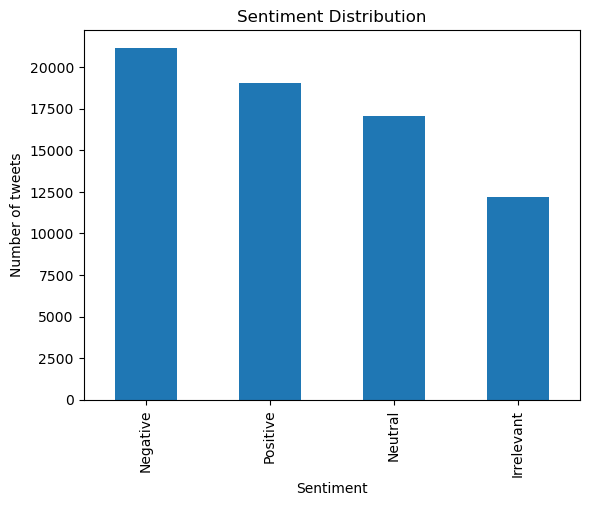

Distribution of Sentiment using bar plot (%)


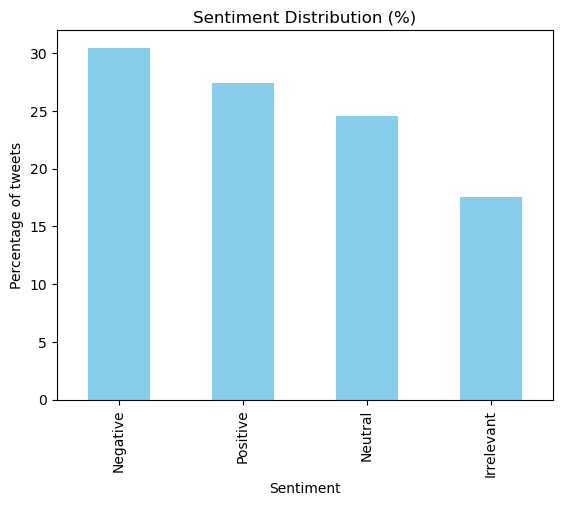

In [13]:
print(""" 
Exploratory Data Analysis (EDA):
Basic Statistics - 
1. Summarise the dataset (mean, median, mode, etc.)
2. Explore the distribution of tweet sentiments (e.g., how many positive, negative, and neutral tweets are there?).
""")    


print(f"Mean of the Sentiment is which shows the average of the sentiment is : {y_train.mean()}")
print(f"Median of the Sentiment is shows the middle value when data is sorted : { y_train.median()}")
print(f"Mode of the Sentiment provides the sentiment with largest occurence : {y_train.mode().iloc[0]}")

print(f"Distribution of Sentiment using bar plot" )
df['Sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of tweets')
plt.show()

print("Distribution of Sentiment using bar plot (%)")
sentiment_pct = df['Sentiment'].value_counts(normalize=True).mul(100).sort_values(ascending=False)
ax = sentiment_pct.plot(kind='bar', color='skyblue')
plt.title('Sentiment Distribution (%)')
plt.xlabel('Sentiment')
plt.ylabel('Percentage of tweets')
plt.show()

 
Visualisations:
Create visualisations to showcase:
1. The distribution of sentiments.
2. The frequency of top words in positive, negative, and neutral sentiments.
3. Word clouds for positive and negative tweets.
4. The relationship between tweet length and sentiment.

The distribution of sentiments is already covered as part of EDA point 2
The frequency of top words in positive, negative and neutral sentiments
Top Positive Words: [('the', 11315), ('i', 8762), ('to', 7334), ('and', 6677), ('a', 5718), ('of', 4881), ('for', 4230), ('is', 4146), ('this', 3848), ('in', 3625)]
Top Negative Words: [('the', 13577), ('i', 9869), ('to', 8794), ('and', 8431), ('a', 7329), ('is', 6594), ('of', 5552), ('@', 4619), ('in', 4610), ('this', 4488)]
Top Nuetral Words: [('the', 10016), ('/', 7438), ('to', 6812), ('and', 6141), ('a', 5692), ('i', 5264), ('of', 4669), ('for', 3885), ('in', 3840), ('.', 3491)]
 Word clouds for positive and negative tweets


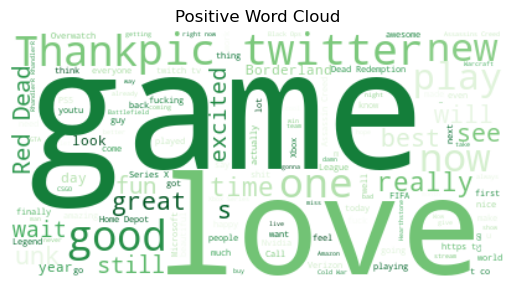

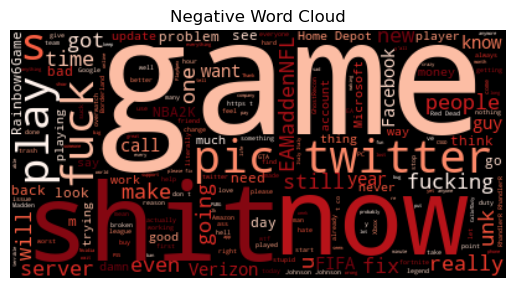

The relationship between tweet length and sentiment


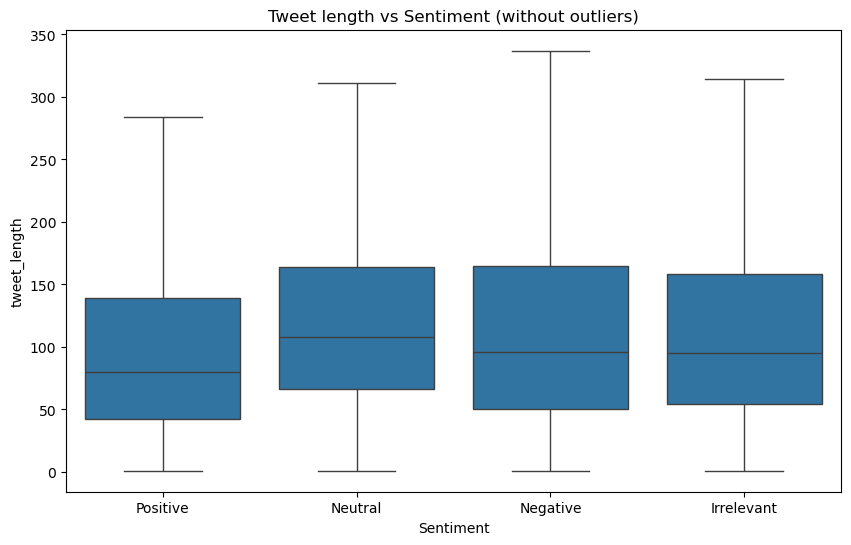

The relationship between tweet length and sentiment with outliers


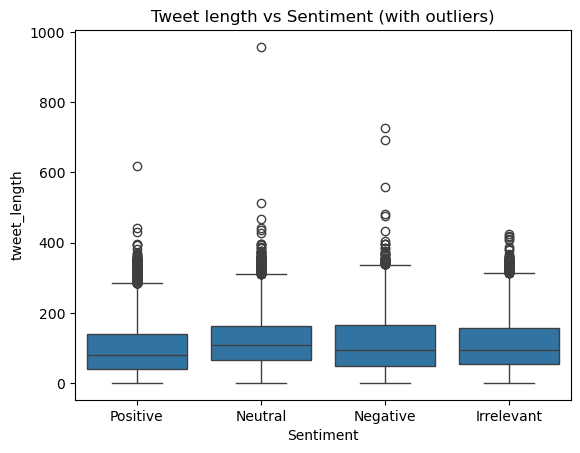

In [14]:
print(""" 
Visualisations:
Create visualisations to showcase:
1. The distribution of sentiments.
2. The frequency of top words in positive, negative, and neutral sentiments.
3. Word clouds for positive and negative tweets.
4. The relationship between tweet length and sentiment.
""")    

# Distribution of sentiments 
print(f"The distribution of sentiments is already covered as part of EDA point 2" )

print(f"The frequency of top words in positive, negative and neutral sentiments" )
def get_top_words(sentiment, data, top_n=10):
    subset = data[data['Sentiment'] == sentiment]
    tokens = []
    for tweet in subset['TweetedText'].fillna(''):
        if isinstance(tweet, list):
            tokens.extend([str(w).lower() for w in tweet])
        else:
            tokens.extend(str(tweet).lower().split())
    return Counter(tokens).most_common(top_n)


top_positive = get_top_words('Positive', df)
top_negative = get_top_words('Negative', df)
top_neutral = get_top_words('Neutral', df)

print("Top Positive Words:", top_positive)
print("Top Negative Words:", top_negative)
print("Top Nuetral Words:", top_neutral)

print(f" Word clouds for positive and negative tweets" )
subset = df.loc[df['Sentiment'] == 'Positive', 'TweetedText']
pos_text = " ".join(subset.fillna('').astype(str))

subset = df.loc[df['Sentiment'] == 'Negative', 'TweetedText']
neg_text = " ".join(subset.fillna('').astype(str))

# Generate Positive Word Cloud
pos_cloud = WordCloud(background_color='white', colormap='Greens').generate(pos_text)
# Generate Negative Word Cloud
neg_cloud = WordCloud(background_color='black', colormap='Reds').generate(neg_text)

plt.title('Positive Word Cloud')
plt.imshow(pos_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

plt.title('Negative Word Cloud')
plt.imshow(neg_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

print(f"The relationship between tweet length and sentiment" )
df['tweet_length'] = df['TweetedText'].fillna('').astype(str).str.len()
ids_to_name = {0: "Neutral", 1: "Irrelevant", 2: "Negative", 3: "Positive"}
df['Sentiment_Label'] = df['Sentiment'].map(ids_to_name)
plt.figure(figsize=(10, 6)) 
sns.boxplot(x='Sentiment', y='tweet_length', data=df, showfliers=False)
plt.title('Tweet length vs Sentiment (without outliers)')
plt.show()

print(f"The relationship between tweet length and sentiment with outliers" )
sns.boxplot(x='Sentiment', y='tweet_length', data=df, showfliers=True)
plt.title('Tweet length vs Sentiment (with outliers)')
plt.show()


In [15]:
print(""" 
Insights:
Write a brief summary of your findings from the EDA. What patterns or trends did you observe in the sentiment distribution?

Summary --> 
1. Negative tweets are generally longer
2. Positive tweets are generally shorter but have the maximum outliers 
3. The frequency of nuetral workds is much higher than that of positive ir negative words
4. The maximum number of tweets in the dataset are of negative sentiment 
""") 

 
Insights:
Write a brief summary of your findings from the EDA. What patterns or trends did you observe in the sentiment distribution?

Summary --> 
1. Negative tweets are generally longer
2. Positive tweets are generally shorter but have the maximum outliers 
3. The frequency of nuetral workds is much higher than that of positive ir negative words
4. The maximum number of tweets in the dataset are of negative sentiment 



In [16]:
print("""
Building transfer-learning RNN model
- Embedding layer initialized with pretrained GloVe-Twitter vectors
- Phase 1: freeze embeddings
- Phase 2: unfreeze and fine-tune with low LR
""")

num_classes = len(np.unique(y_train))
print("\nBuilding the GRU model with pretrained embeddings...")

model = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=EMB_DIM,
        weights=[embedding_matrix],
        trainable=False,   # Phase 1 frozen
        name='pretrained_embedding'
    ),
    Bidirectional(GRU(64, return_sequences=True)),
    Dropout(0.30),
    Bidirectional(GRU(32)),
    Dropout(0.20),
    Dense(64, activation='relu'),
    Dropout(0.20),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Building transfer-learning RNN model
- Embedding layer initialized with pretrained GloVe-Twitter vectors
- Phase 1: freeze embeddings
- Phase 2: unfreeze and fine-tune with low LR


Building the GRU model with pretrained embeddings...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ (None, 200, 100)       │     1,000,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        63,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,099,268 (4.19 MB)

 Trainable params: 99,268 (387.77 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [17]:
# Class weights (handles imbalance)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
# soften toward 1.0
alpha = 0.5   # 0=no weighting, 1=full balanced
weights = 1 + alpha * (weights - 1)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

In [18]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    ,
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

In [19]:
print("\nPhase 1: Training with frozen GloVe embedding layer...")
history_phase1 = model.fit(
    X_train_pad, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

# Phase 2: unfreeze embedding for fine-tuning
print("\nPhase 2: Fine-tuning with unfrozen embedding layer...")
model.get_layer('pretrained_embedding').trainable = True
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # very low LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

# Merge histories for plotting convenience
history = tf.keras.callbacks.History()
history.history = {}
for k in history_phase1.history.keys():
    history.history[k] = history_phase1.history[k] + history_phase2.history[k]



Phase 1: Training with frozen GloVe embedding layer...
Epoch 1/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 173s 476ms/step - accuracy: 0.4993 - loss: 1.1850 - val_accuracy: 0.5572 - val_loss: 1.0586 - learning_rate: 0.0010
Epoch 2/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 174s 499ms/step - accuracy: 0.5666 - loss: 1.0685 - val_accuracy: 0.5782 - val_loss: 1.0173 - learning_rate: 0.0010
Epoch 3/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 316s 910ms/step - accuracy: 0.5972 - loss: 1.0057 - val_accuracy: 0.5956 - val_loss: 0.9686 - learning_rate: 0.0010
Epoch 4/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 143s 410ms/step - accuracy: 0.6269 - loss: 0.9437 - val_accuracy: 0.6192 - val_loss: 0.9273 - learning_rate: 0.0010
Epoch 5/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 143s 411ms/step - accuracy: 0.6579 - loss: 0.8742 - val_accuracy: 0.6454 - val_loss: 0.8823 - learning_rate: 0.0010
Epoch 6/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 139s 400ms/step - accuracy: 0.6881 - loss: 0.8108 - val_accuracy: 0.6568 - val_loss: 0.8598 - learning_rate: 0.0010
Epoch 7/8
348/

In [20]:
#Evaluate the Model
print("\nEvaluating the model on test data...")
y_pred_prob = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred_prob, axis=1)  # Get the predicted class labels

print('First 10 predictions:', y_pred_classes[:10])

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

# Display detailed classification metrics for each category
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_classes,     
    labels=[0, 1, 2, 3],
    target_names=['Neutral', 'Irrelevant', 'Negative', 'Positive']
    ))


# Generate the confusion matrix
conf_matrix_RF = confusion_matrix(y_test, y_pred_classes)
print(f'\nConfusion Matrix:\n{conf_matrix_RF}')

precision = precision_score(y_test, y_pred_classes,average='macro')
recall = recall_score(y_test, y_pred_classes,average='macro')
f1 = f1_score(y_test, y_pred_classes,average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")



Evaluating the model on test data...
435/435 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step
First 10 predictions: [0 3 2 2 3 2 0 3 2 3]
Model Accuracy: 71.11%

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.74      0.63      0.68      3408
  Irrelevant       0.63      0.65      0.64      2443
    Negative       0.75      0.79      0.77      4234
    Positive       0.70      0.73      0.72      3813

    accuracy                           0.71     13898
   macro avg       0.70      0.70      0.70     13898
weighted avg       0.71      0.71      0.71     13898


Confusion Matrix:
[[2137  308  478  485]
 [ 194 1599  273  377]
 [ 278  291 3353  312]
 [ 295  344  380 2794]]
Precision: 0.7042
Recall:    0.7016
F1-Score:  0.7015


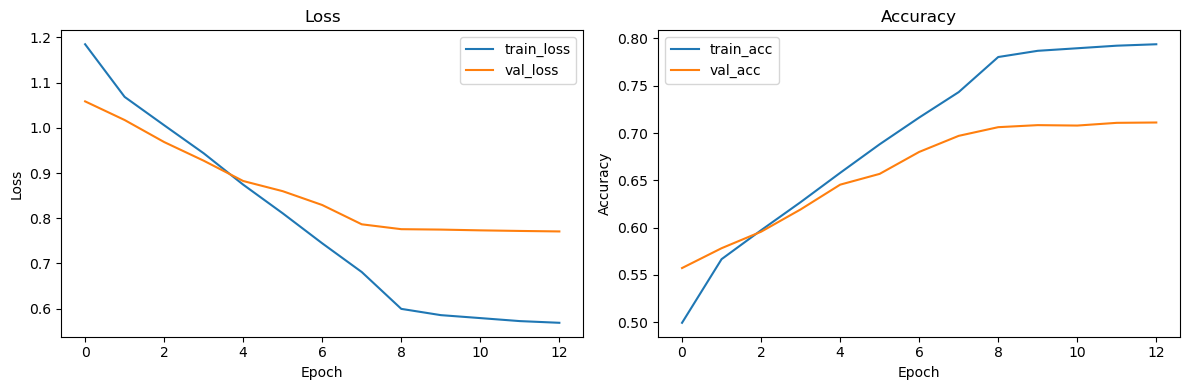

In [21]:
# 8) Training curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()